# Aufgabe 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

## 2.1

(np.float64(-0.5), np.float64(399.5), np.float64(599.5), np.float64(-0.5))

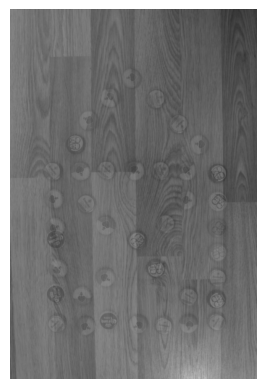

In [2]:
imgs = [imread(f"kombibild/bild{i}.png") for i in range(1, 5)]

clean_img = np.sum(imgs, axis=0) / len(imgs)
plt.imshow(clean_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

4 Bilder reichen nicht aus, um das Rauschen vollständig zu entfernen.

## 2.2

(np.float64(-0.5), np.float64(399.5), np.float64(599.5), np.float64(-0.5))

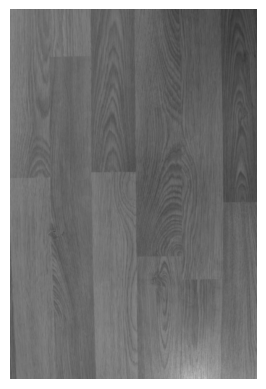

In [3]:
clean_median = np.median(imgs, axis=0)
plt.imshow(clean_median, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

Mit dem Median kann in diesem Fall das Rauschen besser entfernt werden, da Bilder das Rauschen nicht gleichzeitig an der gleichen Stelle haben. Dadurch entfernt der Median die Ausreißer besser als der Durchschnitt.

## 2.3

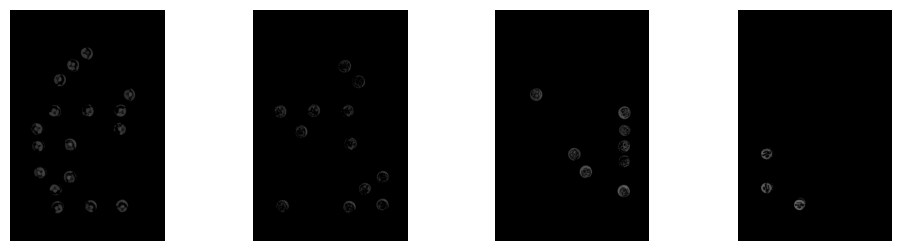

In [4]:
min_diff = 30

real_diffs = np.abs(imgs - clean_median)

new_diffs = np.where(real_diffs > min_diff, real_diffs, 0)

plt.figure(figsize=(12, 3))
for idx, diff in enumerate(new_diffs, 1):
    plt.subplot(1, 4, idx)
    plt.imshow(diff, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
plt.show()

## 3.4

Bild 1: 8694 Pixel ersetzt
Bild 2: 4570 Pixel ersetzt
Bild 3: 4570 Pixel ersetzt
Bild 4: 1522 Pixel ersetzt

Ergebnisbild gespeichert als 'kombibild/result.png'


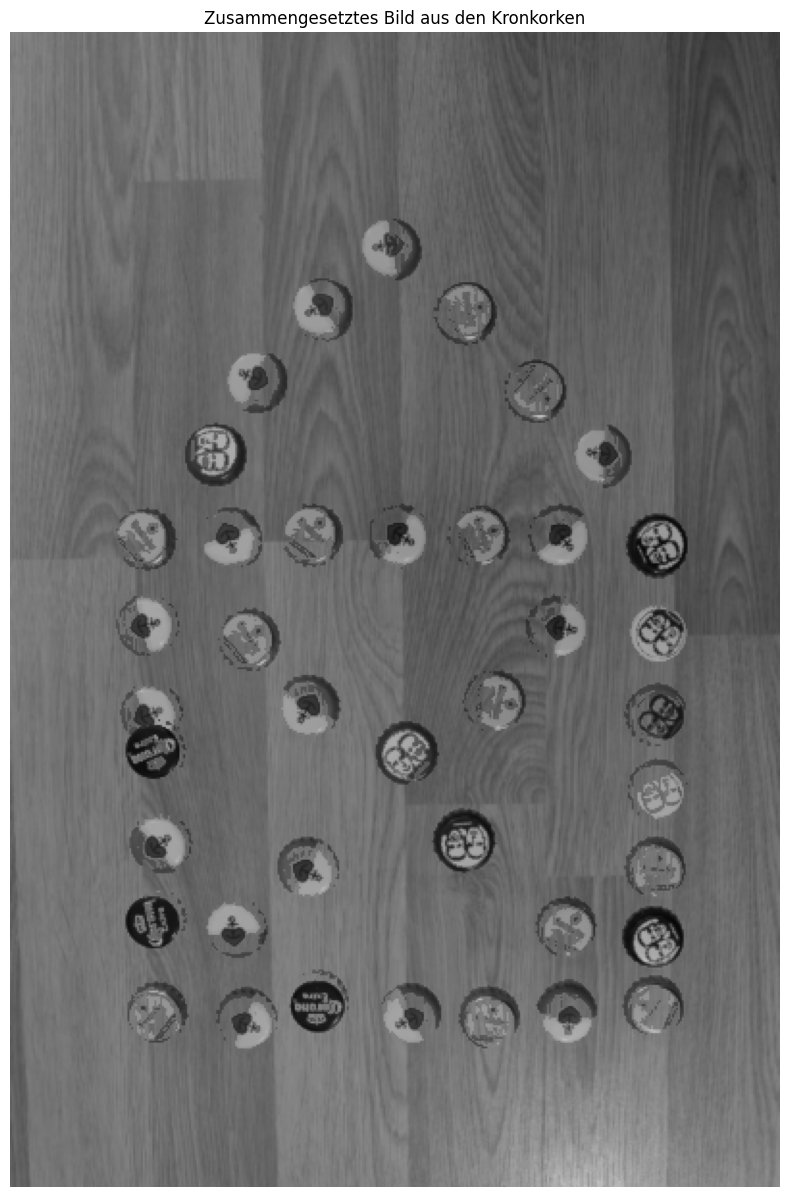

In [5]:
from skimage.io import imsave

# Kopiere das Hintergrundbild (Median)
result_img = clean_median.copy()

# Für jedes der vier Bilder: ersetze veränderte Pixel
for i, img in enumerate(imgs):
    # Berechne die Differenz zwischen Einzelbild und Hintergrundbild
    diff = np.abs(img.astype(float) - clean_median.astype(float))
    # Finde Pixel, die sich signifikant unterscheiden
    mask = diff > min_diff
    # Ersetze diese Pixel im Ergebnisbild
    result_img[mask] = img[mask]
    print(f"Bild {i+1}: {np.sum(mask)} Pixel ersetzt")

# Speichere das Ergebnisbild ab
imsave("kombibild/result.png", result_img.astype(np.uint8))
print("\nErgebnisbild gespeichert als 'kombibild/result.png'")

# Visualisiere das Ergebnis
plt.figure(figsize=(10, 15))
plt.imshow(result_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Zusammengesetztes Bild aus den Kronkorken")
plt.show()